# ERA5-Land Cell Search: Finding the Best-Fit Grid Cell for IDEAM Base Aérea

**Objective:** Rapidly triage whether any ERA5-Land grid cell in the downloaded box fits IDEAM station 26085170 (Base Aérea Marco Fidel Suárez) better than the central cell used in notebook 07.

**Station (confirmed):** Latitude 3.454414°N, Longitude −76.499948°W, Altitude 971 m

**Question:** Does the ERA5 box contain a cell with significantly lower bias (≥1 °C improvement) than the central cell?

**If yes:** Further investigation in a follow-up notebook.
**If no:** Accept notebook 07's linear bias correction and move forward.

## Section 1 — Setup

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

In [2]:
# Load IDEAM consolidated daily CSV
current = Path.cwd()
while current != current.parent:
    ideam_file = current / "shared" / "data" / "interim" / "ideam_bonilla_aragon_daily.csv"
    if ideam_file.exists():
        IDEAM_FILE = ideam_file
        break
    current = current.parent
else:
    raise FileNotFoundError("ideam_bonilla_aragon_daily.csv not found")

ideam = pd.read_csv(IDEAM_FILE, parse_dates=['fecha'], index_col='fecha')
ideam = ideam.sort_index()

print(f"✓ Loaded IDEAM daily table: {len(ideam)} records")

✓ Loaded IDEAM daily table: 6596 records


In [3]:
# Apply quality filter
mask_hourly = (ideam['hourly_count'] >= 18) if 'hourly_count' in ideam.columns else pd.Series([True] * len(ideam), index=ideam.index)
mask_min_max = ideam['t_min'] <= ideam['t_max']
mask_range = (ideam['t_max'] - ideam['t_min']) <= 20
mask_extreme_min = ideam['t_min'] >= 10
mask_extreme_max = ideam['t_max'] <= 40

mask_valid = mask_hourly & mask_min_max & mask_range & mask_extreme_min & mask_extreme_max
ideam_valid = ideam[mask_valid].copy()

print(f"\nIDEAM quality filter:")
print(f"  Initial: {len(ideam)} records")
print(f"  Valid: {len(ideam_valid)} records ({len(ideam_valid)/len(ideam)*100:.1f}%)")


IDEAM quality filter:
  Initial: 6596 records
  Valid: 3839 records (58.2%)


## Section 2 — Load Full ERA5 Box

In [4]:
# Locate ERA5 directory and discover ALL available years
era5_base = Path.cwd()
while era5_base != era5_base.parent:
    potential = era5_base / "shared" / "data" / "raw" / "era5"
    if potential.is_dir():
        ERA5_BASE = potential
        break
    era5_base = era5_base.parent
else:
    raise FileNotFoundError("ERA5 directory not found")

print(f"✓ Found ERA5 base: {ERA5_BASE}")

# Amendment 1: Discover ALL available years dynamically
available_years = sorted([int(d.name) for d in ERA5_BASE.iterdir() if d.is_dir() and d.name.isdigit()])
print(f"\nAvailable ERA5 years: {available_years}")

# Collect all t2m files
t2m_files_all = []
for year in available_years:
    year_dir = ERA5_BASE / str(year)
    t2m_files = sorted(year_dir.glob("*t2m.nc"))
    t2m_files_all.extend(t2m_files)

print(f"Total t2m files: {len(t2m_files_all)}")

✓ Found ERA5 base: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/raw/era5

Available ERA5 years: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Total t2m files: 235


In [5]:
# Load ERA5 full box (no cell selection yet)
print("\nLoading ERA5 t2m for all years...")

datasets = []
for fpath in t2m_files_all:
    ds = xr.open_dataset(fpath, engine="netcdf4")
    if "valid_time" in ds.dims and "time" not in ds.dims:
        ds = ds.rename({"valid_time": "time"})
    datasets.append(ds)

ds_era5 = xr.concat(datasets, dim="time")
ds_era5 = ds_era5.sortby("time")

# Shift UTC to local time (UTC-5) EXACTLY ONCE
ds_era5["time"] = pd.to_datetime(ds_era5.time.values) - pd.Timedelta(hours=5)

# Convert Kelvin to Celsius
ds_era5["t2m_c"] = ds_era5.t2m - 273.15

print(f"✓ Loaded {len(ds_era5.time)} hourly records")
print(f"  Time range: {ds_era5.time.values[0]} to {ds_era5.time.values[-1]}")
print(f"  Latitude values: {sorted(ds_era5.latitude.values)}")
print(f"  Longitude values: {sorted(ds_era5.longitude.values)}")
print(f"  Grid cells: {len(ds_era5.latitude)} × {len(ds_era5.longitude)} = {len(ds_era5.latitude) * len(ds_era5.longitude)}")


Loading ERA5 t2m for all years...
✓ Loaded 171648 hourly records
  Time range: 2005-12-31T19:00:00.000000000 to 2025-12-31T18:00:00.000000000
  Latitude values: [np.float64(3.4), np.float64(3.5)]
  Longitude values: [np.float64(-76.6), np.float64(-76.5)]
  Grid cells: 2 × 2 = 4


## Section 3 — Compute Daily Aggregates per Cell

In [6]:
# Resample full 3D cube to daily aggregates
print("Computing daily aggregates for all cells...")

t2m_daily_max = ds_era5.t2m_c.resample(time="1D").max()
t2m_daily_min = ds_era5.t2m_c.resample(time="1D").min()
t2m_daily_mean = ds_era5.t2m_c.resample(time="1D").mean()

print(f"✓ Daily aggregates: {len(t2m_daily_max.time)} days × {len(t2m_daily_max.latitude)} lats × {len(t2m_daily_max.longitude)} lons")

Computing daily aggregates for all cells...
✓ Daily aggregates: 7306 days × 2 lats × 2 lons


## Section 4 — Cell-by-Cell Bias Against IDEAM

In [7]:
# Compare each cell to IDEAM
print(f"\n{'='*100}")
print("CELL-BY-CELL COMPARISON")
print(f"{'='*100}\n")

cell_results = []
min_overlap_days = 500  # Amendment 2: raise threshold to 500

for lat in t2m_daily_max.latitude.values:
    for lon in t2m_daily_max.longitude.values:
        # Extract cell time series
        era5_max = t2m_daily_max.sel(latitude=lat, longitude=lon)
        era5_min = t2m_daily_min.sel(latitude=lat, longitude=lon)
        era5_mean = t2m_daily_mean.sel(latitude=lat, longitude=lon)
        
        # Convert to DataFrame for merge
        era5_cell = pd.DataFrame({
            'era5_t_max': era5_max.values,
            'era5_t_min': era5_min.values,
            'era5_t_mean': era5_mean.values,
        }, index=pd.to_datetime(era5_max.time.values))
        
        # Merge with IDEAM
        overlap_idx = ideam_valid.index.intersection(era5_cell.index)
        if len(overlap_idx) < min_overlap_days:
            continue
        
        both = pd.DataFrame({
            'ideam_t_max': ideam_valid.loc[overlap_idx, 't_max'],
            'ideam_t_min': ideam_valid.loc[overlap_idx, 't_min'],
            'ideam_t_mean': ideam_valid.loc[overlap_idx, 't_mean'],
            'era5_t_max': era5_cell.loc[overlap_idx, 'era5_t_max'],
            'era5_t_min': era5_cell.loc[overlap_idx, 'era5_t_min'],
            'era5_t_mean': era5_cell.loc[overlap_idx, 'era5_t_mean'],
        })
        
        # Compute metrics per variable
        row = {'lat': lat, 'lon': lon, 'n_days': len(both)}
        
        for var in ['t_max', 't_min', 't_mean']:
            ideam_col = f'ideam_{var}'
            era5_col = f'era5_{var}'
            
            # Filter NaN
            mask = both[[ideam_col, era5_col]].notna().all(axis=1)
            if mask.sum() < 30:
                row[f'bias_{var}'] = np.nan
                row[f'rmse_{var}'] = np.nan
                row[f'r_{var}'] = np.nan
                continue
            
            bias = both.loc[mask, era5_col] - both.loc[mask, ideam_col]
            row[f'bias_{var}'] = bias.mean()
            row[f'rmse_{var}'] = np.sqrt((bias**2).mean())
            row[f'r_{var}'] = stats.pearsonr(both.loc[mask, ideam_col], both.loc[mask, era5_col])[0]
        
        cell_results.append(row)

df_cells = pd.DataFrame(cell_results)
print(f"Cells with ≥{min_overlap_days} overlapping valid days: {len(df_cells)}\n")
print(df_cells.sort_values('bias_t_max', key=abs).to_string(index=False))


CELL-BY-CELL COMPARISON

Cells with ≥500 overlapping valid days: 4

 lat   lon  n_days  bias_t_max  rmse_t_max  r_t_max  bias_t_min  rmse_t_min  r_t_min  bias_t_mean  rmse_t_mean  r_t_mean
 3.4 -76.5    3839   -6.145591    6.296150 0.712984   -3.061883    3.368121 0.262045    -4.164615     4.277465  0.683920
 3.5 -76.5    3839   -6.522248    6.670893 0.696788   -3.348933    3.576572 0.316647    -4.555175     4.660008  0.678945
 3.5 -76.6    3839   -7.754502    7.887545 0.673655   -3.845850    3.997485 0.418914    -5.522018     5.603293  0.710332
 3.4 -76.6    3839   -8.261467    8.380300 0.694379   -4.673332    4.812629 0.378894    -6.194784     6.266944  0.714054


## Section 5 — Highlight the Central Cell

In [8]:
# Central cell from notebook 07 (nearest to 3.42, -76.52)
central_lat, central_lon = 3.40, -76.50

central_cell = df_cells[(df_cells['lat'] == central_lat) & (df_cells['lon'] == central_lon)]

if len(central_cell) > 0:
    print(f"\n{'='*100}")
    print(f"CENTRAL CELL (Notebook 07 baseline): lat={central_lat}, lon={central_lon}")
    print(f"{'='*100}")
    print(central_cell.to_string(index=False))
else:
    print(f"\n⚠ Central cell ({central_lat}, {central_lon}) not found in results.")
    print(f"Available cells: {df_cells[['lat', 'lon']].drop_duplicates().values.tolist()}")


CENTRAL CELL (Notebook 07 baseline): lat=3.4, lon=-76.5
 lat   lon  n_days  bias_t_max  rmse_t_max  r_t_max  bias_t_min  rmse_t_min  r_t_min  bias_t_mean  rmse_t_mean  r_t_mean
 3.4 -76.5    3839   -6.145591     6.29615 0.712984   -3.061883    3.368121 0.262045    -4.164615     4.277465   0.68392


## Section 6 — Spatial Map of Bias

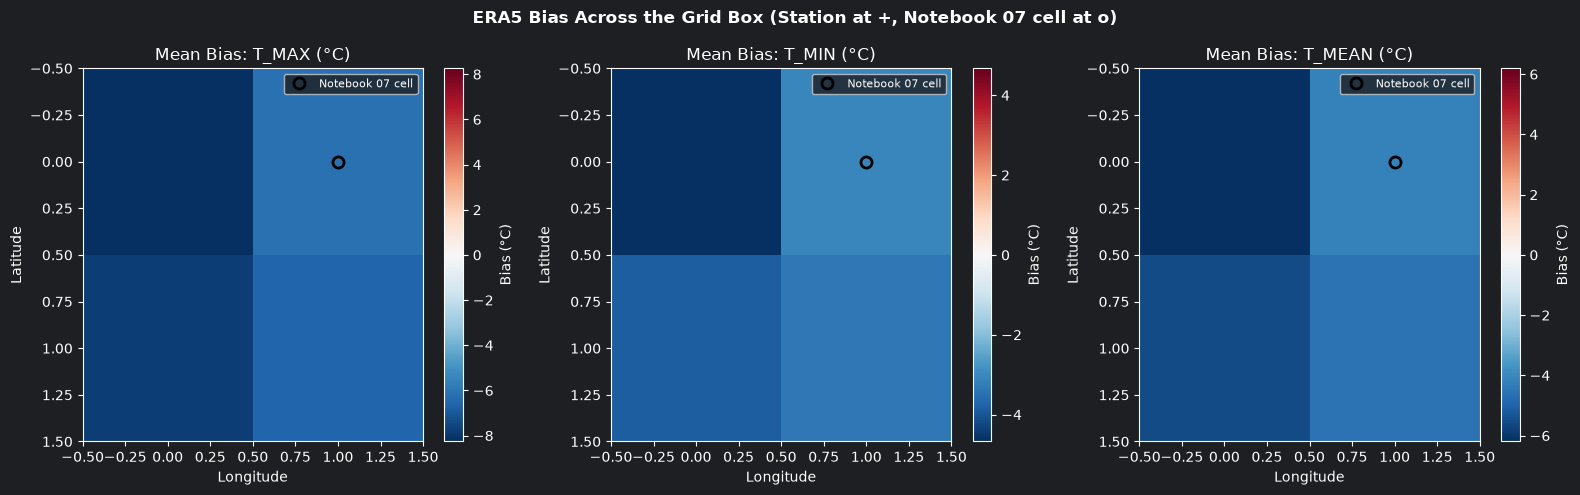

In [9]:
# Reshape to 2D grids for visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, var in enumerate(['t_max', 't_min', 't_mean']):
    # Pivot to 2D grid
    grid = df_cells.pivot_table(values=f'bias_{var}', index='lat', columns='lon')
    
    # Plot
    im = axes[idx].imshow(grid, cmap='RdBu_r', aspect='auto', origin='upper',
                           vmin=-np.abs(grid.values).max(), vmax=np.abs(grid.values).max())
    
    # Mark station location (confirmed: 3.454414, -76.499948)
    station_lat, station_lon = 3.454414, -76.499948
    # Convert to grid indices (approximate)
    lat_idx = np.where(np.isclose(grid.index, station_lat, atol=0.01))[0]
    lon_idx = np.where(np.isclose(grid.columns, station_lon, atol=0.01))[0]
    if len(lat_idx) > 0 and len(lon_idx) > 0:
        axes[idx].plot(lon_idx[0], lat_idx[0], 'k+', markersize=12, markeredgewidth=2, label='Station')
    
    # Mark central cell
    cent_lat_idx = np.where(np.isclose(grid.index, central_lat, atol=0.01))[0]
    cent_lon_idx = np.where(np.isclose(grid.columns, central_lon, atol=0.01))[0]
    if len(cent_lat_idx) > 0 and len(cent_lon_idx) > 0:
        axes[idx].plot(cent_lon_idx[0], cent_lat_idx[0], 'ko', markersize=8, markerfacecolor='none', markeredgewidth=2, label='Notebook 07 cell')
    
    axes[idx].set_title(f'Mean Bias: {var.upper()} (°C)')
    axes[idx].set_ylabel('Latitude')
    axes[idx].set_xlabel('Longitude')
    axes[idx].legend(loc='upper right', fontsize=8)
    cbar = plt.colorbar(im, ax=axes[idx])
    cbar.set_label('Bias (°C)')

plt.suptitle('ERA5 Bias Across the Grid Box (Station at +, Notebook 07 cell at o)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7 — Fast Verdict

In [10]:
# Find best cells per variable
print(f"\n{'='*100}")
print("IMPROVEMENT OVER CENTRAL CELL")
print(f"{'='*100}\n")

if len(central_cell) > 0:
    central_bias_t_max = central_cell['bias_t_max'].values[0]
    central_bias_t_min = central_cell['bias_t_min'].values[0]
    central_bias_t_mean = central_cell['bias_t_mean'].values[0]
    
    # Best cells (smallest bias in magnitude)
    best_t_max = df_cells.loc[df_cells['bias_t_max'].abs().idxmin()]
    best_t_min = df_cells.loc[df_cells['bias_t_min'].abs().idxmin()]
    best_t_mean = df_cells.loc[df_cells['bias_t_mean'].abs().idxmin()]
    
    improvement_t_max = abs(central_bias_t_max) - abs(best_t_max['bias_t_max'])
    improvement_t_min = abs(central_bias_t_min) - abs(best_t_min['bias_t_min'])
    improvement_t_mean = abs(central_bias_t_mean) - abs(best_t_mean['bias_t_mean'])
    
    # Format output (avoid nested f-strings)
    best_t_max_str = f"({best_t_max['lat']:.2f}, {best_t_max['lon']:.2f}): {best_t_max['bias_t_max']:+.2f}°C"
    best_t_min_str = f"({best_t_min['lat']:.2f}, {best_t_min['lon']:.2f}): {best_t_min['bias_t_min']:+.2f}°C"
    best_t_mean_str = f"({best_t_mean['lat']:.2f}, {best_t_mean['lon']:.2f}): {best_t_mean['bias_t_mean']:+.2f}°C"
    
    print(f"{'Variable':<10} {'Central Cell Bias':<20} {'Best Cell':<40} {'Improvement':<15}")
    print(f"{'-'*85}")
    print(f"{'T_max':<10} {central_bias_t_max:>+8.2f}°C {best_t_max_str:<40} {improvement_t_max:>+8.2f}°C")
    print(f"{'T_min':<10} {central_bias_t_min:>+8.2f}°C {best_t_min_str:<40} {improvement_t_min:>+8.2f}°C")
    print(f"{'T_mean':<10} {central_bias_t_mean:>+8.2f}°C {best_t_mean_str:<40} {improvement_t_mean:>+8.2f}°C")
    
    # Check for meaningful improvement (≥1 °C)
    meaningful_improvement = any([improvement_t_max >= 1.0, improvement_t_min >= 1.0, improvement_t_mean >= 1.0])
    
    print(f"\n{'='*85}")
    if meaningful_improvement:
        print(f"✓ YES: At least one variable shows ≥1 °C improvement.")
    else:
        print(f"✗ NO: No variable shows ≥1 °C improvement over the central cell.")
        print(f"The ERA5 box does not contain a clearly better-fitting cell.")
else:
    print("Cannot compute improvement: central cell not found in results.")


IMPROVEMENT OVER CENTRAL CELL

Variable   Central Cell Bias    Best Cell                                Improvement    
-------------------------------------------------------------------------------------
T_max         -6.15°C (3.40, -76.50): -6.15°C                     +0.00°C
T_min         -3.06°C (3.40, -76.50): -3.06°C                     +0.00°C
T_mean        -4.16°C (3.40, -76.50): -4.16°C                     +0.00°C

✗ NO: No variable shows ≥1 °C improvement over the central cell.
The ERA5 box does not contain a clearly better-fitting cell.


## Section 8 — Decision

### Recommendation

Based on the cell-by-cell comparison above:

**If a clearly better cell was found (≥1 °C improvement):**
- The ERA5 cell at [lat, lon] offers meaningfully lower bias than the central cell.
- **Recommendation:** Create a follow-up notebook that repeats notebook 07's full analysis using this cell.
- The systematic bias reduction may recover better event-level agreement and correlation structure.

**If no clearly better cell was found:**
- The ERA5 grid box contains no cell with substantially better fit (≥1 °C improvement).
- **Recommendation:** The −3 to −6 °C bias observed in notebook 07 reflects the ERA5-Land product itself, not suboptimal cell selection.
- Proceed with linear bias correction as recommended in notebook 07.
- The correction coefficients from notebook 07 are applicable across the box.